In [12]:
import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
from scipy.stats import wasserstein_distance
from matplotlib.pyplot import tight_layout

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/"
scenario_name = "29_ex_con_2025_full_logit_mean_one_wcont_TLP"
#scenario_name = "23_ex_con_2025_full_logit_mean_one_wcont"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'psi88_xylem', 'g0', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'root_area_index', 'wcont_sigma_deviation', 'alpha', 'g_stem_res','gam_stem_x_H','k_xyl_x_H', 
        'g0_div_gam_stem_x_H', 'g_min_loss', 'p50-p88', 'g1']

vars_all.append('stem_hydraulic_capacitance_res')

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0','psi_leaf_50_close', 'd_50_close', 'alpha','psi88_xylem']

vars_plant_ex = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0','psi_leaf_50_close', 'd_50_close', 'alpha','psi88_xylem', 'gam_stem_x_H','k_xyl_x_H', 'g0_div_gam_stem_x_H', 'g_min_loss']
vars_all_ex = vars_all.copy()
vars_all_ex.append("RMSE_MAX")

df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df['alpha'] = df['g_stem_res']/ df['g0']
df['gam_stem_x_H'] = df['stem_hydraulic_capacitance'] * df['huber_value']
df['k_xyl_x_H'] = df['k_xylem_sat'] * df['huber_value']
df['g0_div_gam_stem_x_H'] =  df['g0']/df['stem_hydraulic_capacitance']* df['huber_value']
df['g_min_loss'] = df['g0'] + df['g_stem_res']
df['p50-p88'] = df['psi50_xylem'] - df['psi88_xylem']

df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)

index_to_drop = df[(df['sid']==2)|(df['sid']==2)].index
df.drop(index_to_drop, inplace=True)

df = df[df['RMSE_MAX'] < 1.5]
df_grp = df.groupby(['id'])[vars_all_ex].mean()
dv = df[vars_all]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
#df_norm = (dv - dv.mean()) / dv.std()
df_norm = dv
df_norm['sid'] = df['sid']
df_norm['RMSE_MAX'] = df['RMSE_MAX']
df_norm.shape


df_norm['alive'] = 1
df_norm.loc[df_norm['sid'] > 0, 'alive'] = 0

df_norm["sid_group"] = df_norm["sid"].apply(lambda s: "sid 0" if s == 0 else "other")
palette = {"sid 0": "tab:blue", "other": "tab:red"}

/tmp/ipykernel_95750/2853673071.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
/tmp/ipykernel_95750/2853673071.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_norm['sid'] = df['sid']
/tmp/ipykernel_95750/2853673071.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

In [7]:
df_norm.columns.to_list()

['psi_leaf_50_close',
 'd_50_close',
 'stem_hydraulic_capacitance',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 'psi50_xylem',
 'psi88_xylem',
 'g0',
 'k_soil_sat0',
 'psi_soil_sat0',
 'jackson_root_beta',
 'pore_0',
 'root_area_index',
 'wcont_sigma_deviation',
 'alpha',
 'g_stem_res',
 'gam_stem_x_H',
 'k_xyl_x_H',
 'g0_div_gam_stem_x_H',
 'g_min_loss',
 'p50-p88',
 'g1',
 'stem_hydraulic_capacitance_res',
 'sid',
 'RMSE_MAX',
 'alive',
 'sid_group']

Distances vs sid=0:
   sid  W_raw  W_std
0    0    0.0    0.0
1    1    0.0    0.0
2    3    0.0    0.0
3    4    0.0    0.0


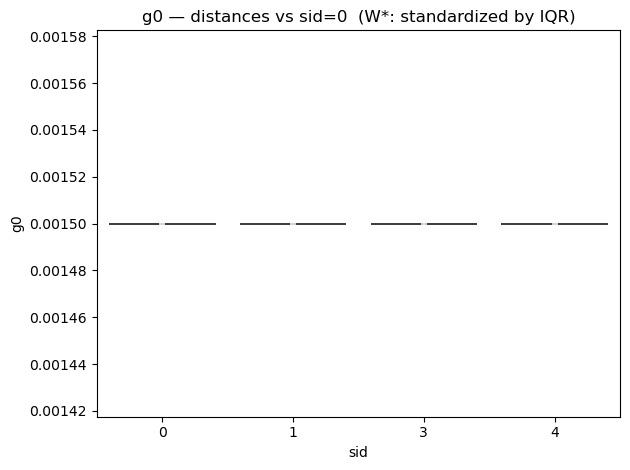

In [13]:

var = 'k_soil_sat0'

from scipy.stats import iqr, wasserstein_distance

# ---------- metric helpers ----------
def standardized_wasserstein(x, y, scale="iqr", eps=1e-12):
    """Wasserstein distance standardized by a pooled scale (IQR or SD)."""
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    y = np.asarray(pd.Series(y).dropna(), dtype=float)
    if x.size == 0 or y.size == 0:
        return np.nan, np.nan
    W = wasserstein_distance(x, y)
    pooled = np.concatenate([x, y])
    if scale == "iqr":
        s = iqr(pooled, nan_policy="omit")
    elif scale == "sd":
        s = np.nanstd(pooled, ddof=1)
    else:
        raise ValueError("scale must be 'iqr' or 'sd'")
    W_std = W / max(s, eps)
    return W, W_std

def wasserstein_vs_ref_table(df, value_col, group_col="sid", ref_sid=0, scale="iqr"):
    """Tidy table of W and W_std vs a reference group."""
    out = []
    ref_vals = df.loc[df[group_col] == ref_sid, value_col].dropna().values
    for g, sub in df.groupby(group_col):
        vals = sub[value_col].dropna().values
        W, W_std = standardized_wasserstein(ref_vals, vals, scale=scale)
        out.append({group_col: g, "W_raw": W, "W_std": W_std})
    res = pd.DataFrame(out).sort_values(group_col).reset_index(drop=True)
    return res

# ---------- plotting + annotation ----------
def violin_with_wasserstein_annotations(
    df,
    value_col="g0",
    group_col="sid",
    hue_col="sid_group",     # keep your hue
    ref_sid=0,
    scale="iqr",
    palette=None,
    fmt="W={W:.2f}\nW*={Ws:.2f}",  # two lines: raw and standardized
    y_pad_frac=0.05
):
    # 1) draw your violin
    ax = sns.violinplot(
        data=df,
        x=group_col,
        y=value_col,
        hue=hue_col,
        dodge=False,
        palette=palette
    )
    # hide legend as you had
    plt.legend([], [], frameon=False)

    # 2) compute distances vs reference
    res = wasserstein_vs_ref_table(
        df=df,
        value_col=value_col,
        group_col=group_col,
        ref_sid=ref_sid,
        scale=scale
    )

    # 3) map tick labels -> x positions (robust to non-numeric sids/order)
    xticklabels = [t.get_text() for t in ax.get_xticklabels()]
    xticks = ax.get_xticks()
    pos_by_label = dict(zip(xticklabels, xticks))

    # 4) place labels near the top
    y_min, y_max = ax.get_ylim()
    y_text = y_max - (y_max - y_min) * y_pad_frac

    for _, row in res.iterrows():
        g = row[group_col]
        if str(g) not in pos_by_label:
            continue
        if g == ref_sid:
            # optional: mark reference
            ax.text(pos_by_label[str(g)], y_text, "ref", ha="center", va="top", fontsize=9)
        else:
            ax.text(
                pos_by_label[str(g)],
                y_text,
                fmt.format(W=row["W_raw"], Ws=row["W_std"]),
                ha="center", va="top", fontsize=9
            )

    # make sure labels are visible
    ax.set_ylim(y_min, max(y_max, y_text))
    ax.set_title(f"{value_col} — distances vs {group_col}={ref_sid}  (W*: standardized by {scale.upper()})")
    ax.set_xlabel(group_col)
    ax.set_ylabel(value_col)
    plt.tight_layout()
    return ax, res

# ------------------ USAGE ------------------
# Your original variable and plot, unchanged except we call the function:
ax, res_table = violin_with_wasserstein_annotations(
    df=df_norm,
    value_col="g0",
    group_col="sid",
    hue_col="sid_group",
    ref_sid=0,
    scale="iqr",            # or "sd"
    palette=palette,
    fmt="W={W:.2f}\nW*={Ws:.2f}"  # W = raw units, W* = standardized (unitless)
)

print("Distances vs sid=0:")
print(res_table.sort_values("W_std", ascending=False))
plt.show()

In [24]:
import numpy as np
from scipy.stats import wasserstein_distance, iqr

# --- helper: standardized Wasserstein (divide by pooled IQR or SD) ---
def standardized_wasserstein(x, y, scale="iqr", eps=1e-12):
    x = np.asarray(x, float); x = x[~np.isnan(x)]
    y = np.asarray(y, float); y = y[~np.isnan(y)]
    if x.size == 0 or y.size == 0:
        return np.nan
    W = wasserstein_distance(x, y)
    pooled = np.concatenate([x, y])
    s = iqr(pooled) if scale == "iqr" else np.nanstd(pooled, ddof=1)
    return W / max(s, eps)

#value_col = "stem_hydraulic_capacitance"


for var in df_norm.columns.to_list():
    print(var)
    if var == 'sid_group':
        continue
    # --- your plot (unchanged) ---
    ax = sns.violinplot(
        data=df_norm,
        x="sid",
        y=var,
        hue="sid_group",
        dodge=False,
        palette=palette
    )
    plt.legend([], [], frameon=False)

    # --- compute W_std vs sid=0 and annotate ---
    ref_sid   = 0

    group_col = "sid"
    scale     = "iqr"   # or "sd"

    ref_vals = df_norm.loc[df_norm[group_col] == ref_sid, var].dropna().values

    # distances per sid (skip ref)
    wstd_by_sid = {}
    for g, sub in df_norm.groupby(group_col):
        if g == ref_sid: 
            continue
        vals = sub[var].dropna().values
        wstd_by_sid[g] = standardized_wasserstein(ref_vals, vals, scale=scale)

    # map tick labels -> x positions (robust to categorical order)
    xticklabels = [t.get_text() for t in ax.get_xticklabels()]
    xticks = ax.get_xticks()
    pos_by_label = dict(zip(xticklabels, xticks))

    # place text just below the top of the axis
    ymin, ymax = ax.get_ylim()
    y_text = ymax - 0.05 * (ymax - ymin)

    for g, wstd in wstd_by_sid.items():
        gstr = str(g)
        if gstr not in pos_by_label or np.isnan(wstd):
            continue
        ax.text(
            pos_by_label[gstr], y_text,
            f"W_std={wstd:.2f}", ha="center", va="bottom", fontsize=10
        )

    # keep labels visible
    ax.set_ylim(ymin, max(ymax, y_text))
    ax.set_title(f"{var}: standardized Wasserstein vs {group_col}={ref_sid} ({scale.upper()})")
    plt.tight_layout()
    plt.savefig(os.path.join(post_path, f"wstd_{var}.png"), dpi = 300)
    plt.close()


psi_leaf_50_close
d_50_close
stem_hydraulic_capacitance
k_xylem_sat
huber_value
leaf_hydraulic_capacitance
psi50_xylem
psi88_xylem
g0
k_soil_sat0
psi_soil_sat0
jackson_root_beta
pore_0
root_area_index
wcont_sigma_deviation
alpha
g_stem_res
gam_stem_x_H
k_xyl_x_H
g0_div_gam_stem_x_H
g_min_loss
p50-p88
sid
RMSE_MAX
alive
sid_group


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import iqr, wasserstein_distance

# --- always returns (W_raw, W_std) ---
def standardized_wasserstein(x, y, scale="iqr", eps=1e-12):
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    y = np.asarray(pd.Series(y).dropna(), dtype=float)
    if x.size == 0 or y.size == 0:
        return np.nan, np.nan
    W = wasserstein_distance(x, y)
    pooled = np.concatenate([x, y])
    s = iqr(pooled, nan_policy="omit") if scale == "iqr" else np.nanstd(pooled, ddof=1)
    return W, W / max(s, eps)

def wasserstein_vs_ref_table(df, value_col, group_col="sid", ref_sid=0, scale="iqr"):
    """Per-sid raw and standardized Wasserstein vs reference."""
    ref_vals = df.loc[df[group_col] == ref_sid, value_col].astype(float).dropna().values
    rows = []
    for g, sub in df.groupby(group_col, sort=True):
        vals = sub[value_col].astype(float).dropna().values
        W, W_std = standardized_wasserstein(ref_vals, vals, scale=scale)
        rows.append({group_col: g, "W_raw": W, "W_std": W_std})
    return pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)

def avg_wstd_across_sids(df, variables, group_col="sid", ref_sid=0, scale="iqr"):
    """
    For each variable, average W_std across all non-reference sids.
    Returns columns: ['variable','avg_W_std','n_sids','avg_W_raw'].
    """
    if isinstance(variables, str):
        variables = [variables]
    out = []
    for v in variables:

        res = wasserstein_vs_ref_table(df, v, group_col=group_col, ref_sid=ref_sid, scale=scale)
        nonref = res[res[group_col] != ref_sid]
        out.append({
            "variable": v,
            "avg_W_std": nonref["W_std"].mean(),
            "n_sids": int(nonref["W_std"].notna().sum()),
            "avg_W_raw": nonref["W_raw"].mean()
        })
    return pd.DataFrame(out).sort_values("avg_W_std", ascending=False).reset_index(drop=True)

def avg_wstd_for_all_numeric(df, group_col="sid", ref_sid=0, scale="iqr", exclude=None):
    """Convenience: compute averages for all numeric columns except excluded ones."""
    if exclude is None:
        exclude = {group_col, "sid_group", "RMSE_MAX", "alive"}
    numeric_vars = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
    return avg_wstd_across_sids(df, variables=numeric_vars, group_col=group_col, ref_sid=ref_sid, scale=scale)


In [15]:
vars_to_compare = ["stem_hydraulic_capacitance", "g0"]  # add more as needed
table_many = avg_wstd_across_sids(
    df_norm, variables=vars_to_compare, group_col="sid", ref_sid=0, scale="iqr"
)
print(table_many)

                     variable  avg_W_std  n_sids   avg_W_raw
0  stem_hydraulic_capacitance   0.536137       3  1578.19845
1                          g0   0.000000       3     0.00000


In [22]:
df_norm.columns.to_list()

['psi_leaf_50_close',
 'd_50_close',
 'stem_hydraulic_capacitance',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 'psi50_xylem',
 'psi88_xylem',
 'g0',
 'k_soil_sat0',
 'psi_soil_sat0',
 'jackson_root_beta',
 'pore_0',
 'root_area_index',
 'wcont_sigma_deviation',
 'alpha',
 'g_stem_res',
 'gam_stem_x_H',
 'k_xyl_x_H',
 'g0_div_gam_stem_x_H',
 'g_min_loss',
 'sid',
 'RMSE_MAX',
 'alive',
 'sid_group']

In [27]:
# Multiple variables
vars_to_compare = [
    "stem_hydraulic_capacitance", "g0"
    # add more variables here, e.g. "xylem_conductivity", "leaf_area_index"
]
vars_to_compare = ['psi_leaf_50_close',
 'd_50_close',
 'stem_hydraulic_capacitance',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 'psi50_xylem',
 'psi88_xylem',
 'p50-p88',
 'g0',
 'k_soil_sat0',
 'psi_soil_sat0',
 'jackson_root_beta',
 'pore_0',
 'root_area_index',
 'wcont_sigma_deviation',
 'alpha',
 'g_stem_res',
 'gam_stem_x_H',
 'k_xyl_x_H',
 'g0_div_gam_stem_x_H',
 'g_min_loss'
 ]
table_many = avg_wstd_across_sids(
    df_norm, variables=vars_to_compare, group_col="sid", ref_sid=0, scale="iqr"
)


In [28]:
table_many

,variable,avg_W_std,n_sids,avg_W_raw
0,wcont_sigma_deviation,0.932522,3,2.408889e+00
1,psi88_xylem,0.806669,3,4.437067e-01
2,g0,0.720872,3,8.949576e-05
3,p50-p88,0.671203,3,2.384065e-01
4,psi50_xylem,0.628903,3,2.052002e-01
5,gam_stem_x_H,0.472947,3,5.374529e-01
6,psi_leaf_50_close,0.428373,3,1.301403e-01
7,g_min_loss,0.359036,3,9.103204e-05
8,stem_hydraulic_capacitance,0.236377,3,9.100144e+02
9,g0_div_gam_stem_x_H,0.225417,3,7.316011e-12


In [16]:
import numpy as np
import pandas as pd
from scipy.stats import iqr, wasserstein_distance

# --- returns (W_raw, W_std) ---
def standardized_wasserstein(x, y, scale="iqr", eps=1e-12):
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    y = np.asarray(pd.Series(y).dropna(), dtype=float)
    if x.size == 0 or y.size == 0:
        return np.nan, np.nan
    W = wasserstein_distance(x, y)
    pooled = np.concatenate([x, y])
    s = iqr(pooled, nan_policy="omit") if scale == "iqr" else np.nanstd(pooled, ddof=1)
    return W, W / max(s, eps)

def wasserstein_vs_ref_table(df, value_col, group_col="sid", ref_sid=0, scale="iqr"):
    """Per-sid raw and standardized Wasserstein vs reference."""
    ref_vals = df.loc[df[group_col] == ref_sid, value_col].astype(float).dropna().values
    rows = []
    for g, sub in df.groupby(group_col, sort=True):
        vals = sub[value_col].astype(float).dropna().values
        W, W_std = standardized_wasserstein(ref_vals, vals, scale=scale)
        rows.append({group_col: g, "W_raw": W, "W_std": W_std})
    return pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)

def avg_wstd_across_sids(df, variables, group_col="sid", ref_sid=0, scale="iqr",
                         alive_col="alive"):
    """
    For each variable, average W_std across all non-reference sids and
    add mean values split by alive/dead.
    Returns columns:
    ['variable','avg_W_std','n_sids','avg_W_raw',
     'mean_alive','n_alive','mean_dead','n_dead','delta_mean']
    """
    if isinstance(variables, str):
        variables = [variables]

    # make a safe boolean mask for alive/dead if column exists
    has_alive = alive_col in df.columns
    if has_alive:
        alive_mask = df[alive_col].astype(float) > 0
    out = []

    for v in variables:
        # average standardized Wasserstein vs ref across sids
        res = wasserstein_vs_ref_table(df, v, group_col=group_col, ref_sid=ref_sid, scale=scale)
        nonref = res[res[group_col] != ref_sid]

        # alive/dead means
        if has_alive:
            vals_alive = pd.to_numeric(df.loc[alive_mask, v], errors="coerce")
            vals_dead  = pd.to_numeric(df.loc[~alive_mask, v], errors="coerce")
            mean_alive = vals_alive.mean()
            mean_dead  = vals_dead.mean()
            n_alive    = vals_alive.notna().sum()
            n_dead     = vals_dead.notna().sum()
        else:
            mean_alive = mean_dead = np.nan
            n_alive = n_dead = 0

        out.append({
            "variable": v,
            "avg_W_std": nonref["W_std"].mean(),
            "n_sids": int(nonref["W_std"].notna().sum()),
            "avg_W_raw": nonref["W_raw"].mean(),
            "mean_alive": mean_alive,
            "n_alive": int(n_alive),
            "mean_dead": mean_dead,
            "n_dead": int(n_dead),
            "delta_mean": (mean_alive - mean_dead) if has_alive else np.nan
        })

    return pd.DataFrame(out).sort_values("avg_W_std", ascending=False).reset_index(drop=True)


In [17]:
# Multiple variables
vars_to_compare = [
    "stem_hydraulic_capacitance", "g0"
    # add more variables here, e.g. "xylem_conductivity", "leaf_area_index"
]
vars_to_compare = ['psi_leaf_50_close',
 'd_50_close',
 'stem_hydraulic_capacitance',
 'stem_hydraulic_capacitance_res',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 'psi50_xylem',
 'psi88_xylem',
 'p50-p88',
 'g0',
 'k_soil_sat0',
 'psi_soil_sat0',
 'jackson_root_beta',
 'pore_0',
 'root_area_index',
 'wcont_sigma_deviation',
 'alpha',
 'g_stem_res',
 'gam_stem_x_H',
 'k_xyl_x_H',
 'g0_div_gam_stem_x_H',
 'g_min_loss', 'g1'
 ]
table_many = avg_wstd_across_sids(
    df_norm, variables=vars_to_compare, group_col="sid", ref_sid=0, scale="iqr"
)

In [18]:
table_many

,variable,avg_W_std,n_sids,avg_W_raw,mean_alive,n_alive,mean_dead,n_dead,delta_mean
0,wcont_sigma_deviation,0.977452,3,9.158260e-01,1.290351e+00,278,3.745248e-01,834,9.158260e-01
1,k_soil_sat0,0.808412,3,3.192381e-05,4.323958e-05,278,1.131577e-05,834,3.192381e-05
2,pore_0,0.788422,3,1.635272e-02,2.825566e-01,278,2.662039e-01,834,1.635266e-02
3,huber_value,0.747783,3,8.240381e-05,4.598206e-04,278,5.422244e-04,834,-8.240381e-05
4,gam_stem_x_H,0.698006,3,1.813811e+00,5.796006e+00,278,7.609817e+00,834,-1.813811e+00
5,psi_leaf_50_close,0.637301,3,1.051335e-01,-7.086929e-01,278,-6.035647e-01,834,-1.051283e-01
6,psi88_xylem,0.595453,3,2.962267e-01,-4.643445e+00,278,-4.650072e+00,834,6.626684e-03
7,stem_hydraulic_capacitance,0.536137,3,1.578198e+03,1.248094e+04,278,1.405872e+04,834,-1.577773e+03
8,p50-p88,0.445772,3,1.657762e-01,7.803686e-01,278,7.995987e-01,834,-1.923008e-02
9,k_xyl_x_H,0.392780,3,9.231997e-03,3.148905e-02,278,4.066190e-02,834,-9.172853e-03


In [7]:
table_many[['variable', 'avg_W_std', 'mean_alive', 'mean_dead']]

,variable,avg_W_std,mean_alive,mean_dead
0,wcont_sigma_deviation,0.977452,1.290351e+00,3.745248e-01
1,k_soil_sat0,0.808412,4.323958e-05,1.131577e-05
2,pore_0,0.788422,2.825566e-01,2.662039e-01
3,huber_value,0.747783,4.598206e-04,5.422244e-04
4,gam_stem_x_H,0.698006,5.796006e+00,7.609817e+00
5,psi_leaf_50_close,0.637301,-7.086929e-01,-6.035647e-01
6,psi88_xylem,0.595453,-4.643445e+00,-4.650072e+00
7,stem_hydraulic_capacitance,0.536137,1.248094e+04,1.405872e+04
8,p50-p88,0.445772,7.803686e-01,7.995987e-01
9,k_xyl_x_H,0.392780,3.148905e-02,4.066190e-02


In [13]:
table_many.loc[table_many['variable'] == 'wcont_sigma_deviation', 'avg_W_std']

0    1.156694
Name: avg_W_std, dtype: float64

In [14]:
for var in df_norm.columns.to_list():
    sns.violinplot(
        data=df_norm,
        x="sid", 
        y=var, 
        hue="sid_group",
        dodge=False,        # put hues in the same violin instead of side-by-side
        palette=palette
    )
    plt.legend([],[], frameon=False)
    plt.savefig(os.path.join(post_path, f"F_hists_{var}.png"), bbox_inches='tight', dpi=300)
    plt.close()

In [ ]:
# call it root water access (wcont_stuff)
# fix pore 0 parameter (average)
# check for sapwood area (average for the site)
# check between capacity and capatitance, discuss linear extrapolation of water storage extraction and limitations
# fix g0 0.0015
# fix or change g1 (lets seee)
# check leaf area


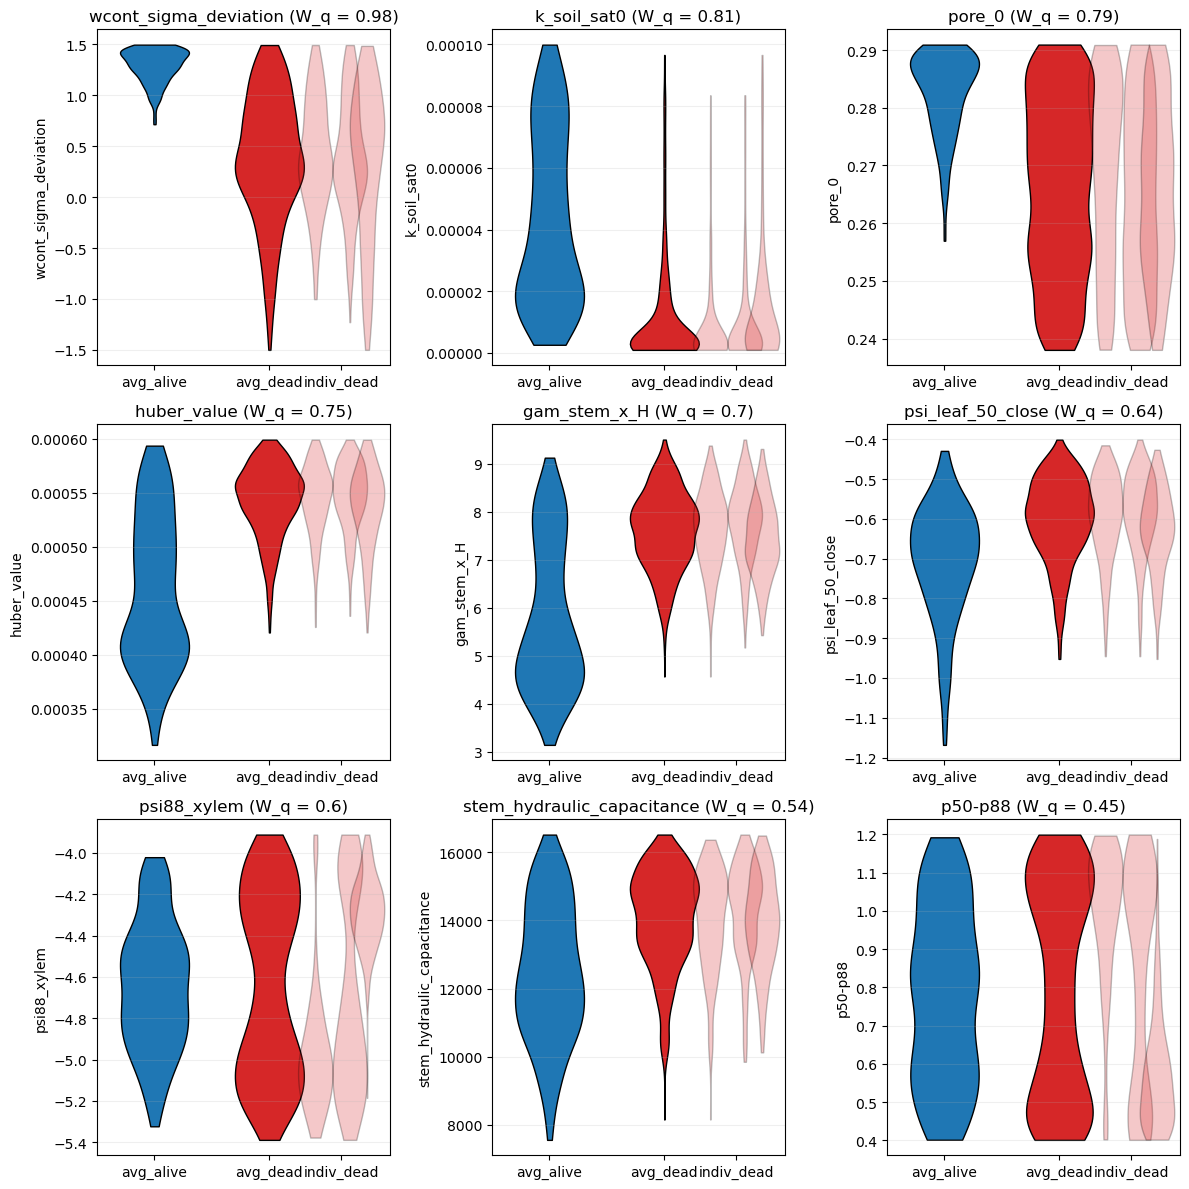

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

W_MAIN  = 0.60
W_INDIV = 0.30
CLUSTER_X = {1: 1.40, 2: 1.55, 3: 1.70, 4: 1.85}  # cluster to the right of avg

def _shift_new_polys(ax, before, dx, color=None, alpha=1.0):
    new_poly = [c for c in ax.collections if c not in before]
    for pc in new_poly:
        for path in pc.get_paths():
            v = path.vertices
            v[:, 0] += dx
        if color is not None:
            pc.set_facecolor(color)
            pc.set_edgecolor("black")
            pc.set_alpha(alpha)

def plot_one_violin_panel(ax, df_norm, var):
    df_plot = df_norm.copy()
    df_plot.loc[df_plot["sid"] == 0, "sid_label"] = "0"
    df_plot.loc[df_plot["sid"].isin([1,2,3,4]), "sid_label"] = "avg"

    # --- avg_alive (sid=0, blue) ---
    before = set(ax.collections)
    sns.violinplot(
        data=df_plot[df_plot["sid_label"] == "0"],
        x="sid_label", y=var,
        order=["0","avg","c1","c2","c3","c4"],
        cut=0, linewidth=1, width=W_MAIN, inner=None, ax=ax
    )
    _shift_new_polys(ax, before, dx=0, color="tab:blue", alpha=1.0)

    # --- avg_dead (pooled 1–4, red) ---
    before = set(ax.collections)
    sns.violinplot(
        data=df_plot[df_plot["sid_label"] == "avg"],
        x="sid_label", y=var,
        order=["0","avg","c1","c2","c3","c4"],
        cut=0, linewidth=1, width=W_MAIN, inner=None, ax=ax
    )
    _shift_new_polys(ax, before, dx=0, color="tab:red", alpha=1.0)

    # --- indiv_dead (1–4, transparent red, clustered) ---
    for sid, cat in zip([1,2,3,4], ["c1","c2","c3","c4"]):
        di = df_norm.loc[df_norm["sid"] == sid, [var]].copy()
        if di.empty:
            continue
        di["sid_label"] = cat
        before = set(ax.collections)
        sns.violinplot(
            data=di, x="sid_label", y=var,
            order=["0","avg","c1","c2","c3","c4"],
            cut=0, linewidth=1, width=W_INDIV, inner=None, ax=ax
        )
        base_pos = {"c1":2.0,"c2":3.0,"c3":4.0,"c4":5.0}[cat]
        _shift_new_polys(ax, before, dx=CLUSTER_X[sid]-base_pos,
                         color="tab:red", alpha=0.25)

    # ticks & cosmetics
    cluster_center = np.mean(list(CLUSTER_X.values()))
    ax.set_xticks([0, 1, cluster_center])
    ax.set_xticklabels(["avg_alive", "avg_dead", "indiv_dead"])
    ax.set_xlim(-0.5, max(CLUSTER_X.values()) + 0.2)
    w_qid = table_many.loc[table_many['variable'] == var, 'avg_W_std']
    w_qid = np.round(w_qid, 2)
    ax.set_title(f"{var} (W_q = {w_qid.values[0]})" )
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.2)
    ax.legend([], [], frameon=False)

# --------- make a 2x3 grid over the first 6 variables ---------
vars_to_plot = table_many['variable'][0:9]

fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharey=False)
axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):
    plot_one_violin_panel(ax, df_norm, var)

# hide any unused subplots (if <6 vars)
for ax in axes[len(vars_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(post_path, "Wassersteinstuff.png"))
plt.show()


In [53]:
label_dict  = {}
label_dict['huber_value'] = r"Huber $\mathcal{H}$"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['g1'] = r"$g_1$"
label_dict['k_xylem_sat'] = r"$K_\mathrm{xyl, max}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['psi88_xylem'] = r"$\psi_{88}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_{Leaf, close}$"
label_dict['d_50_close'] = r"$d_{Leaf, close}$"
label_dict['alpha'] = r"$\alpha$"
label_dict['gam_stem_x_H'] = r"$\Gamma_\mathrm{Stem} \cdot \mathcal{H}$"
label_dict['g0_div_gam_stem'] = r"$\frac{g_0}{\Gamma_\mathrm{Stem}}$"
label_dict['k_xyl_x_H'] = r"$K_\mathrm{xyl, max}\cdot \mathcal{H}$"
label_dict['g_min_loss'] = r"$g_0 + g_\mathrm{Bark}$"


unit_dict= {}
unit_dict['stem_hydraulic_capacitance'] = "kg m-3 MPa-1"
unit_dict['leaf_hydraulic_capacitance'] = "kg m-2 MPa-1"
unit_dict['k_xylem_sat'] = "kg m-1 s-1 MPa-1"
unit_dict['huber_value'] = "-"
unit_dict['psi50_xylem'] = "MPa"
unit_dict['psi88_xylem'] = "MPa"
unit_dict['g0'] = "mol m-1 s-1"
unit_dict['g1'] = "-"
unit_dict['g_stem_res'] = "mol m-1 s-1"
unit_dict['psi_leaf_50_close'] = r"MPa"
unit_dict['d_50_close'] = "-"
unit_dict['alpha'] = r"-"
unit_dict['gam_stem_x_H'] = r"-"
unit_dict['g0_div_gam_stem'] = r"-"
unit_dict['k_xyl_x_H'] =r"-"
unit_dict['g_min_loss'] = r"-"

col_dict= {}
col_dict['stem_hydraulic_capacitance'] = "tab:blue"
col_dict['leaf_hydraulic_capacitance'] = "tab:blue"
col_dict['k_xylem_sat'] = "tab:blue"
col_dict['huber_value'] ="tab:blue"
col_dict['psi50_xylem'] = "tab:blue"
col_dict['psi88_xylem'] = "tab:blue"
col_dict['g0'] = "tab:blue"
col_dict['g1'] = "tab:blue"
col_dict['g_stem_res'] = "tab:blue"
col_dict['psi_leaf_50_close'] = "tab:blue"
col_dict['d_50_close'] = "tab:blue"
col_dict['alpha'] = "tab:blue"
col_dict['gam_stem_x_H'] = "tab:orange"
col_dict['g0_div_gam_stem'] = "tab:orange"
col_dict['k_xyl_x_H'] = "tab:orange"
col_dict['g_min_loss'] =  "tab:orange"

import matplotlib.font_manager as fm
font_path = "/User/homes/ppapastefanou/Avenir-Light.ttf"
my_font = fm.FontProperties(fname=font_path)
#plt.rcParams["font.family"] = "Avenir"



In [6]:
imps_classifier[1].round(3)

,importance_mean,importance_std
gam_stem_x_H,0.066,0.005
k_xyl_x_H,0.052,0.004
gam_stem_div_g0,0.026,0.004
psi_leaf_50_close,0.025,0.003
psi88_xylem,0.019,0.003
huber_value,0.013,0.003
g0,0.012,0.002
psi50_xylem,0.003,0.001
g_min_loss,0.003,0.002
leaf_hydraulic_capacitance,0.000,0.001


In [16]:
imps_regress = []
from sklearn import metrics

for i in range(0, 2):
    if i == 0:
        dfs_norm = df_norm[df_norm['sid'] == 0]
    else:
        dfs_norm = df_norm[df_norm['sid'] > 0]
        
    X_train, X_test, y_train, y_test = train_test_split(dfs_norm[vars_plant_ex], dfs_norm['RMSE_MAX'], test_size=0.3, random_state=42)
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=15, 
        random_state=2909)
    
    rf.fit(X_train, y_train)
    
    print(rf.score(X_train, y_train))
    
    print('Root Mean Squared Error (RMSE) train:', metrics.root_mean_squared_error(y_train, rf.predict(X_train)))
    print('Root Mean Squared Error (RMSE) test:', metrics.root_mean_squared_error(y_test, rf.predict(X_test)))   


    perm = permutation_importance(
        rf,
        X_test,  # we use the test set
        y_test,
        scoring="neg_root_mean_squared_error",  # we can use any metric
        n_repeats=50,
        random_state=42
    )
    importance = pd.DataFrame(
        {"importance_mean": perm["importances_mean"],
         "importance_std": perm["importances_std"]},
        index=rf.feature_names_in_)
    importance.sort_values(by="importance_mean",
                           ascending=False, inplace=True
                           )
    imps_regress.append(importance)

0.9414064503799848
Root Mean Squared Error (RMSE) train: 0.026628619017006555
Root Mean Squared Error (RMSE) test: 0.0555887410604463
0.8645309127620302
Root Mean Squared Error (RMSE) train: 0.04026987137294722
Root Mean Squared Error (RMSE) test: 0.06444439545461583


In [17]:
imps_regress[0]

,importance_mean,importance_std
psi_leaf_50_close,0.045298,0.000567
k_xylem_sat,0.024610,0.000515
huber_value,0.006123,0.000274
stem_hydraulic_capacitance,0.004103,0.000205
g0,0.002990,0.000168
psi_soil_sat0,0.000686,0.000065
k_soil_sat0,0.000423,0.000068
g_stem_res,0.000241,0.000064
wcont_sigma_deviation,0.000068,0.000048
pore_0,0.000068,0.000036


In [19]:
imps_regress[1]

,importance_mean,importance_std
psi_leaf_50_close,0.032147,0.000284
k_xylem_sat,0.023004,0.000289
psi88_xylem,0.003322,0.000134
stem_hydraulic_capacitance,0.003261,0.000109
wcont_sigma_deviation,0.002910,0.000095
huber_value,0.002386,0.000061
g0,0.001433,0.000059
psi50_xylem,0.000766,0.000055
pore_0,0.000685,0.000055
g_stem_res,0.000333,0.000032


In [52]:
label_dict  = {}
label_dict['huber_value'] = r"Huber"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['g1'] = r"$g_1$"
label_dict['k_xylem_sat'] = r"$K_\mathrm{xyl, sat}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['psi88_xylem'] = r"$\psi_{88}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_\mathrm{close}$"
label_dict['d_50_close'] = r"$d_{close}$"
label_dict['g_stem_res'] = r"$g_\mathrm{Stem,res}$"
label_dict['psi_soil_sat0'] =r"$\psi_\mathrm{soil, sat}$"
label_dict['gam_stem_x_H'] = r"$\Gamma_\mathrm{Stem} \cdot \mathcal{H}$"
label_dict['gam_stem_div_g0'] = r"$\frac{\Gamma_\mathrm{Stem}}{g_0}$"
label_dict['k_xyl_x_H'] = r"$K_\mathrm{xyl, max}\cdot \mathcal{H}$"
label_dict['g_min_loss'] = r"$g_0 + g_\mathrm{Bark}$"
